In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile, os

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/AI_ML_Practice/Week5/FruitinAmazon.zip" # location of my zipfile

EXTRACT_DIR = "./fruitnamazon_dataset" # under current directory (./) create the new folder to store extracted dataset
os.makedirs(EXTRACT_DIR, exist_ok=True) # this is where it actually gets created.

# Unzip the file
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)
print(f"File '{os.path.basename(ZIP_PATH)}' unzipped to '{EXTRACT_DIR}'")

File 'FruitinAmazon.zip' unzipped to './fruitnamazon_dataset'


In [3]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


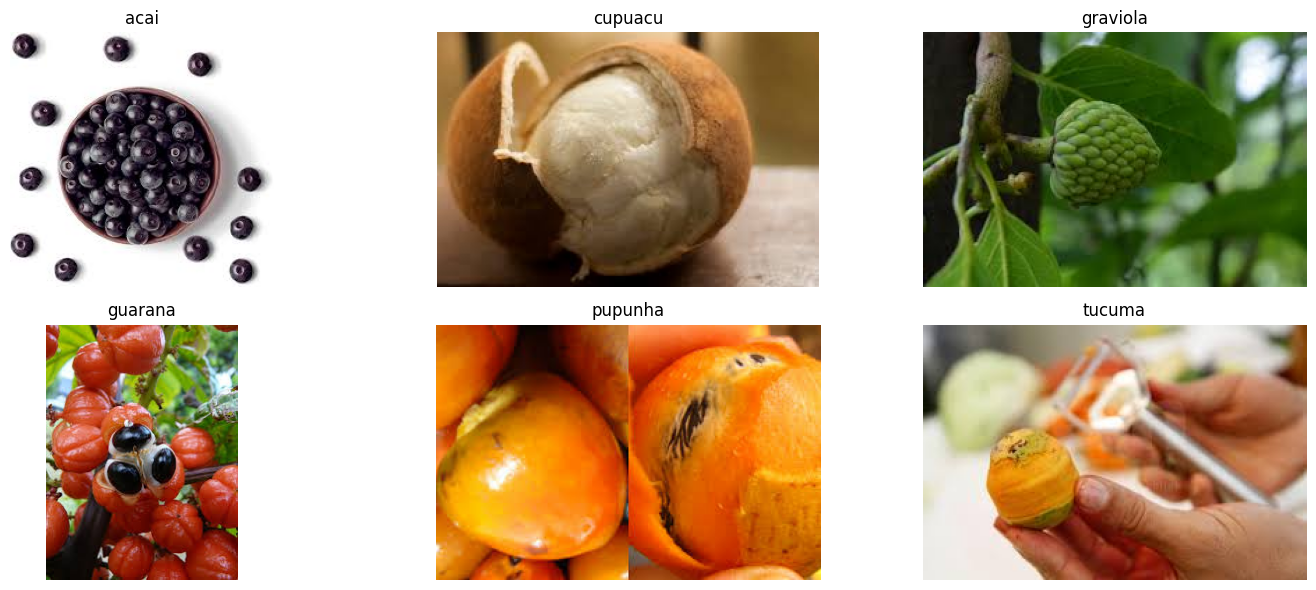

In [12]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to your training data
train_dir = "/content/fruitnamazon_dataset/FruitinAmazon/train"

# 1. Get the list of class directories
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# 2. Setup the grid (2 rows)
num_classes = len(class_names)
cols = (num_classes + 1) // 2  # Calculate columns needed for 2 rows
plt.figure(figsize=(15, 6))

# 3. Select one image randomly from each class and display
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path)

    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:

corrupted_images = []

# Iterate through each class subdirectory
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)

        try:
            # Attempt to load and verify the image
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError):
            # If corrupted, remove and record
            print(f"Removed corrupted image: {image_path}")
            os.remove(image_path)
            corrupted_images.append(image_path)

# Final reporting
if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"Cleaned up {len(corrupted_images)} images.")

No Corrupted Images Found.


In [15]:


# 1. Define specific parameters for your fruit task
img_height, img_width = 28, 28  # Must match your Task 3 architecture
batch_size = 16                 # As specified in Task 4
validation_split = 0.2          # 20% for validation

# 2. Create the normalization layer
# This shifts pixel values from [0, 255] to [0, 1]
rescale = tf.keras.layers.Rescaling(1./255)

# 3. Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',           # Using 'int' works with SparseCategoricalCrossentropy
    color_mode='grayscale',     # Set to 'grayscale' to match (28, 28, 1)
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# 4. Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    color_mode='grayscale',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,              # Validation should not be shuffled
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# 5. Apply Normalization to both
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("\nDatasets are loaded and normalized!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.

Datasets are loaded and normalized!


In [17]:
from tensorflow.keras import layers, models

# 1. Get class names from the directory names directly (since .map() hides them)
# 'train_dir' is the path we used in Task 2
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_names)

print(f"Building model for {num_classes} classes: {class_names}")

# 2. Build the Sequential Model
model = models.Sequential([
    # --- Convolutional Architecture ---

    # Convolutional Layer 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # --- Fully Connected Network Architecture ---
    layers.Flatten(),

    # Hidden Layer 1 (64 neurons)
    layers.Dense(64, activation='relu'),

    # Hidden Layer 2 (128 neurons)
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Building model for 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,078 (465.15 KB)

 Trainable params: 119,078 (465.15 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- Task 4: Compile the Model ---
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- Task 4: Define Callbacks ---
# ModelCheckpoint saves the best version based on validation loss
checkpoint = ModelCheckpoint(
    'best_fruit_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# EarlyStopping stops training if val_loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# --- Task 4: Train the Model ---
# Batch size was already set to 16 in the Task 2 dataset creation
history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)

# --- Task 5: Evaluate the Model ---
print("\n--- Final Evaluation on Validation Set ---")
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")

Epoch 1/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.0625 - loss: 1.8023
Epoch 1: val_loss improved from None to 1.65921, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.1250 - loss: 1.8056 - val_accuracy: 0.8333 - val_loss: 1.6592
Epoch 2/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0625 - loss: 1.8023
Epoch 2: val_loss did not improve from 1.65921
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1806 - loss: 1.7809 - val_accuracy: 0.7778 - val_loss: 1.7024
Epoch 3/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1875 - loss: 1.7629
Epoch 3: val_loss did not improve from 1.65921
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2639 - loss: 1.7653 - val_accuracy: 0.0000e+00 - val_loss: 1.6898
Epoch 4/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2500 - loss: 1.7238
Epoch 4: val_loss did not improve from 1.65921
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1944 - loss: 1.7512 - val_accuracy: 0.0000e+00 - val_loss: 1.7636
Epoch 5/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2500 - loss: 1.7255
Epoc

In [19]:
from tensorflow.keras.models import load_model

# 1. Save the model explicitly
model.save('final_fruit_model.h5')
print("Model saved successfully as 'final_fruit_model.h5'")

# 2. Load the saved model (using the 'best' one saved by our checkpoint)
loaded_model = load_model('best_fruit_model.h5')
print("Best version of the model reloaded successfully!")

# 3. Re-evaluate to prove it works
re_loss, re_acc = loaded_model.evaluate(val_ds)
print(f"Reloaded Model Accuracy: {re_acc*100:.2f}%")

Model saved successfully as 'final_fruit_model.h5'


Best version of the model reloaded successfully!
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8333 - loss: 1.6592 
Reloaded Model Accuracy: 83.33%


In [21]:
from sklearn.metrics import classification_report
import numpy as np

# 1. Extract ground truth and predictions
y_true = []
y_pred_probs = []

print("Generating predictions...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Fix the naming mismatch
# Find which unique class indices are actually in y_true
present_classes_idx = np.unique(y_true)
# Filter class_names to only include those that appeared in the validation set
present_class_names = [class_names[i] for i in present_classes_idx]

# 3. Generate Report
# We pass 'labels' to tell the report exactly which IDs we are reporting on
report = classification_report(
    y_true,
    y_pred,
    labels=present_classes_idx,
    target_names=present_class_names
)

print("\n--- FINAL CLASSIFICATION REPORT ---")
print(report)

Generating predictions...

--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     pupunha       0.00      0.00      0.00         3
      tucuma       0.83      1.00      0.91        15

    accuracy                           0.83        18
   macro avg       0.42      0.50      0.45        18
weighted avg       0.69      0.83      0.76        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
